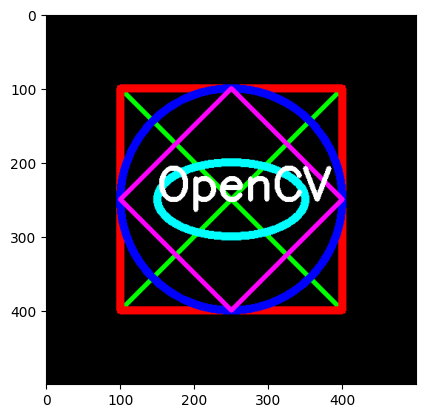

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fun1():
    
    
    bg = np.full(shape=(500,500,3), fill_value=(0,0,0), dtype=np.uint8)
    
    cv2.line(bg,(100,100),(400,400),(0,255,0),5)
    cv2.line(bg,(400,100),(100,400),(0,255,0),5)
    cv2.rectangle(bg,(100,100),(400,400),(0,0,255),10)
    cv2.circle(bg,(250,250),150,(255,0,0),10)
    cv2.ellipse(bg,(250,250),(100,50),0,0,360,(255,255,0),10)
    
    pts = np.array([[100,250],[250,100],[400,250],[250,400]], np.int32)
    cv2.polylines(bg,[pts],True,(255,0,255),5)
    cv2.putText(bg,"OpenCV",(150,250),cv2.FONT_HERSHEY_SIMPLEX,2,(255,255,255),5)
    
    # 将 BGR 转为 RGB，用 matplotlib 内联显示
    bg_rgb = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)
    plt.imshow(bg_rgb)
    plt.axis("on")
    plt.show()
    
    
if __name__ == "__main__":
    fun1()

原图尺寸: (2384, 1179)
缩放后尺寸: (589, 1192)
旋转后尺寸: (1192, 589)


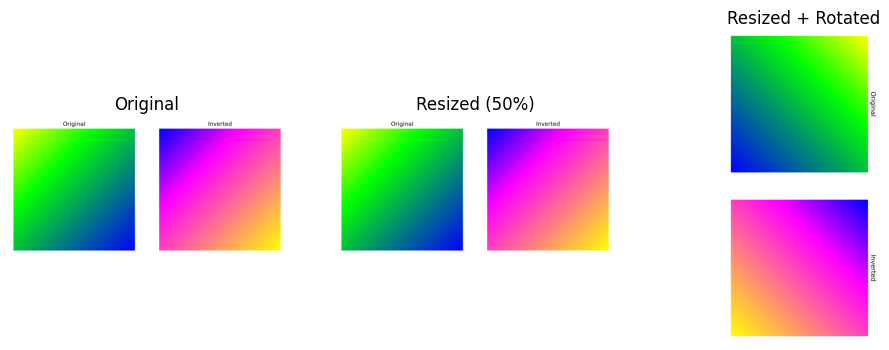

In [61]:
import cv2
import matplotlib.pyplot as plt

def fun2():
    img = cv2.imread("gradient.png")
    print("shape:", img.shape)
    
    pt1 = img[100,100]
    print("BGR at (100,100):", pt1)
    
    # 颜色反转：每个通道值用 255 减去原值
    img_inv = cv2.bitwise_not(img)
    
    # 对比显示原图和反色图
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(img_inv, cv2.COLOR_BGR2RGB))
    plt.title("Inverted")
    plt.axis("off")
    
    # 先保存，再显示
    plt.savefig("inverted.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    
def fun3():
    img = cv2.imread("inverted.png")
    h,w = img.shape[:2]
    print("原图尺寸:", (w, h))
    
    # 1. 缩放图像为原来的一半
    img_resize = cv2.resize(img, (w//2, h//2))
    print("缩放后尺寸:", img_resize.shape[:2])
    
    # 2. 顺时针旋转 90 度
    img_rotate = cv2.rotate(img_resize, cv2.ROTATE_90_CLOCKWISE)
    print("旋转后尺寸:", img_rotate.shape[:2])
    
    # 显示结果
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,3,2)
    plt.imshow(cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB))
    plt.title("Resized (50%)")
    plt.axis("off")
    
    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(img_rotate, cv2.COLOR_BGR2RGB))
    plt.title("Resized + Rotated")
    plt.axis("off")
    plt.show()
    
if __name__ == "__main__":
    fun3()

## 神经网络常见激活函数总结

### 1. Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- **输出范围**: (0, 1)
- **适用场景**: 二分类的输出层（将输出映射为概率）; 传统神经网络的隐藏层（现已少用）
- **缺点**: 容易梯度饱和（两端梯度接近 0），收敛慢; 输出非零均值，不利于深层网络

### 2. Tanh (双曲正切)

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

- **输出范围**: (-1, 1)
- **适用场景**: RNN / LSTM 的门控单元; 适合需要零均值输出的场景
- **缺点**: 仍存在梯度饱和问题

### 3. ReLU (Rectified Linear Unit)

$$\text{ReLU}(x) = \max(0, x)$$

- **输出范围**: [0, +∞)
- **适用场景**: **目前最常用的隐藏层激活函数**; CNN、MLP 等大部分深度学习模型
- **优点**: 计算简单，缓解梯度消失; 稀疏激活
- **缺点**: 部分神经元可能"死亡"（Dead ReLU，即输入为负时梯度永远为 0）

### 4. Leaky ReLU

$$\text{LeakyReLU}(x) = \max(\alpha x, x) \quad (\alpha \text{ 通常取 } 0.01)$$

- **输出范围**: (-∞, +∞)
- **适用场景**: 解决 Dead ReLU 问题时的替代方案
- **优点**: 负区间仍有小梯度，神经元不易死亡

### 5. Softmax

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$$

- **输出范围**: (0, 1)，且所有输出之和为 1
- **适用场景**: **多分类问题的输出层**，输出各类别的概率分布

### 6. Swish / SiLU

$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

- **输出范围**: 近似 (-0.5, +∞)
- **适用场景**: 深层网络（Google 提出，在某些任务上优于 ReLU）
- **优点**: 平滑、非单调，梯度更易流动

### 快速选择指南

| 场景 | 推荐激活函数 |
|------|-------------|
| 隐藏层（默认首选） | **ReLU** |
| 避免 Dead ReLU | Leaky ReLU / PReLU |
| 二分类输出层 | **Sigmoid** |
| 多分类输出层 | **Softmax** |
| RNN / LSTM 门控 | **Tanh** + Sigmoid |
| 深层网络（>= 50 层） | Swish / GELU |
